# [Multivariate Time Series Forecasting with LSTMs in Keras](https://machinelearningmastery.com/multivariate-time-series-forecasting-lstms-keras/)

Neural networks e.g. Long Short-Term Memory (LSTM) recurrent neural networks are able to almost seamlessly model problems with multiple input variables.

This is a great benefit in time series forecasting, where classical linear methods can be difficult to adapt to multivariate or multiple-input forecasting problems.

In this tutorial, you will discover how you can develop an LSTM model for multivariate time series forecasting with the Keras deep learning library.

After completing this tutorial, you will know:

- How to transform a raw dataset into something we can use for time series forecasting.
- How to prepare data and fit an LSTM for a multivariate time series forecasting problem.
- How to make a forecast and rescale the result back into the original units.

## Overview

- [Voraussage der Auslastung eines Parkhauses](https://digital.ebp.ch/2021/01/29/voraussage-der-auslastung-eines-parkhauses-mit-machine-learning/)
- [Barrierefreiheit durch KI_1](https://digital.ebp.ch/2024/05/22/barrierefreiheit-durch-ki-aktualisierung-von-rollstuhlparkplatz-daten-mit-deep-learning-und-luftbildern/)
- [Barrierefreiheit durch KI_2](https://digital.ebp.ch/2024/06/03/barrierefreiheit-durch-ki-aktualisierung-von-rollstuhlparkplatz-daten-mit-deep-learning-und-luftbildern-teil-2/)


- Air Pollution Forecasting
- Basic Data Preparation
- Multivariate LSTM Forecast Model
  - LSTM Data Preparation
  - Define and Fit Model
  - Evaluate Model
  - Complete Example
- Train On Multiple Lag Timesteps Example

## Python Environment

I recommend that you use Python 3 with this tutorial.
This tutorial assumes you have a Python SciPy environment installed. 
You must have Keras (2.0 or higher) installed with either the TensorFlow or Theano backend, Ideally Keras 2.3 and TensorFlow 2.2, or higher.
Libraries: scikit-learn, Pandas, NumPy and Matplotlib.

# 1. Air Pollution Forecasting
In this tutorial, we are going to use the Air Quality dataset.

This is a dataset that reports on the weather and the level of pollution each hour for five years at the US embassy in Beijing, China.

The data includes the date-time, the pollution called PM2.5 concentration, and the weather information including dew point, temperature, pressure, wind direction, wind speed and the cumulative number of hours of snow and rain. The complete feature list in the raw data is as follows:

No: row number
year: year of data in this row
month: month of data in this row
day: day of data in this row
hour: hour of data in this row
pm2.5: PM2.5 concentration
DEWP: Dew Point
TEMP: Temperature
PRES: Pressure
cbwd: Combined wind direction
Iws: Cumulated wind speed
Is: Cumulated hours of snow
Ir: Cumulated hours of rain
We can use this data and frame a forecasting problem where, given the weather conditions and pollution for prior hours, we forecast the pollution at the next hour.

This dataset can be used to frame other forecasting problems.
Do you have good ideas? Let me know in the comments below.

You can download the dataset from the UCI Machine Learning Repository.

Update, I have mirrored the dataset here because UCI has become unreliable:

[Beijing PM2.5 Data Set](https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv)

Download the dataset and place it in your current working directory with the filename “raw.csv“.

# 2. Basic Data Preparation

The data is not ready to use. We must prepare it first.

Below are the first few rows of the raw dataset.

| No | year | month | day | hour | pm2.5 | DEWP | TEMP | PRES | cbwd | Iws  | Is | Ir |
|---:|----:|-----:|---:|----:|:-----|----:|----:|----:|:----|-----:|---:|---:|
| 1 | 2010 | 1 | 1 | 0 | NA | -21 | -11 | 1021 | NW | 1.79 | 0 | 0 |
| 2 | 2010 | 1 | 1 | 1 | NA | -21 | -12 | 1020 | NW | 4.92 | 0 | 0 |
| 3 | 2010 | 1 | 1 | 2 | NA | -21 | -11 | 1019 | NW | 6.71 | 0 | 0 |
| 4 | 2010 | 1 | 1 | 3 | NA | -21 | -14 | 1019 | NW | 9.84 | 0 | 0 |
| 5 | 2010 | 1 | 1 | 4 | NA | -20 | -12 | 1018 | NW | 12.97 | 0 | 0 |

The first step is to consolidate the date-time information into a single date-time so that we can use it as an index in Pandas.

A quick check reveals NA values for pm2.5 for the first 24 hours. We will, therefore, need to remove the first row of data. There are also a few scattered “NA” values later in the dataset; we can mark them with 0 values for now.

The script below loads the raw dataset and parses the date-time information as the Pandas DataFrame index. The “No” column is dropped and then clearer names are specified for each column. Finally, the NA values are replaced with “0” values and the first 24 hours are removed.

The “No” column is dropped and then clearer names are specified for each column. Finally, the NA values are replaced with “0” values and the first 24 hours are removed.

In [1]:
from pandas import read_csv, to_datetime

# load data
dataset = read_csv("raw.csv")

# combine year, month, day, hour into one datetime column
dataset["date"] = to_datetime(dataset[["year", "month", "day", "hour"]])

# use date as index
dataset.set_index("date", inplace=True)

# drop unnecessary columns
dataset.drop(["No", "year", "month", "day", "hour"], axis=1, inplace=True)

# manually specify column names
dataset.columns = ["pollution", "dew", "temp", "press", "wnd_dir", "wnd_spd", "snow", "rain"]
dataset.index.name = "date"

# mark all NA values with 0
dataset["pollution"] = dataset["pollution"].fillna(0)

# drop the first 24 hours
dataset = dataset[24:]

# summarize first 5 rows
print(dataset.head(5))

# save to file
dataset.to_csv("pollution.csv")

                     pollution  dew  temp   press wnd_dir  wnd_spd  snow  rain
date                                                                          
2010-01-02 00:00:00      129.0  -16  -4.0  1020.0      SE     1.79     0     0
2010-01-02 01:00:00      148.0  -15  -4.0  1020.0      SE     2.68     0     0
2010-01-02 02:00:00      159.0  -11  -5.0  1021.0      SE     3.57     0     0
2010-01-02 03:00:00      181.0   -7  -5.0  1022.0      SE     5.36     1     0
2010-01-02 04:00:00      138.0   -7  -5.0  1022.0      SE     6.25     2     0


Running the example prints the first 5 rows of the transformed dataset and saves the dataset to “pollution.csv“.

| date                | pollution | dew | temp | press  | wnd_dir | wnd_spd | snow | rain |
|:--------------------|----------:|----:|-----:|-------:|:--------|--------:|-----:|-----:|
| 2010-01-02 00:00:00 | 129.0     | -16 | -4.0 | 1020.0 | SE      | 1.79    | 0    | 0    |
| 2010-01-02 01:00:00 | 148.0     | -15 | -4.0 | 1020.0 | SE      | 2.68    | 0    | 0    |
| 2010-01-02 02:00:00 | 159.0     | -11 | -5.0 | 1021.0 | SE      | 3.57    | 0    | 0    |
| 2010-01-02 03:00:00 | 181.0     | -7  | -5.0 | 1022.0 | SE      | 5.36    | 1    | 0    |
| 2010-01-02 04:00:00 | 138.0     | -7  | -5.0 | 1022.0 | SE      | 6.25    | 2    | 0    |

Now that we have the data in an easy-to-use form, we can create a quick plot of each series and see what we have.

The code loads the new “pollution.csv” file and plots each series as a separate subplot, except wind speed dir, which is categorical; and creates a plot with 7 subplots showing the 5 years of data for each variable.


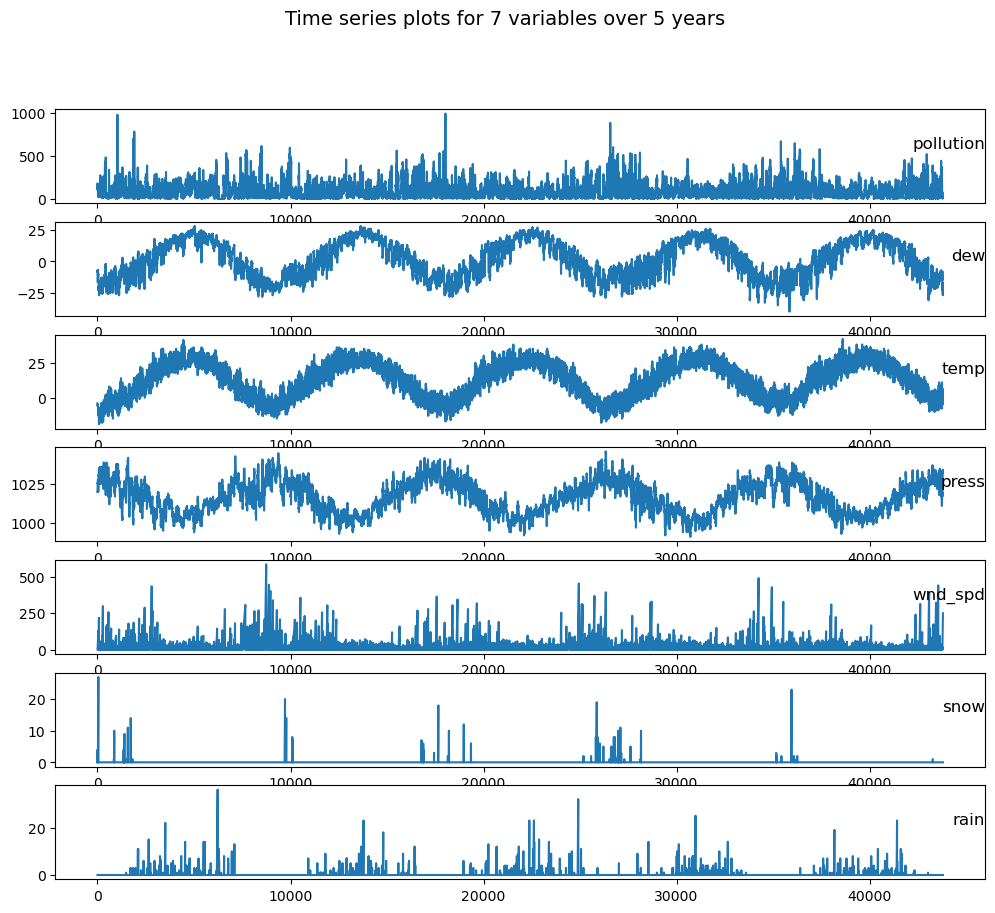

In [2]:
from pandas import read_csv
from matplotlib import pyplot
# load dataset
dataset = read_csv('pollution.csv', header=0, index_col=0)
values = dataset.values
# specify columns to plot
groups = [0, 1, 2, 3, 5, 6, 7]
i = 1

# create figure
pyplot.figure(figsize=(12, 10))
#pyplot.suptitle('7 subplots showing the 5 years of data for each variable', fontsize=14)
#pyplot.suptitle('Five years of pollution and weather variables', fontsize=14)
pyplot.suptitle('Time series plots for 7 variables over 5 years', fontsize=14)

# plot each column
for group in groups:
	pyplot.subplot(len(groups), 1, i)
	pyplot.plot(values[:, group])
	pyplot.title(dataset.columns[group], y=0.5, loc='right')
	i += 1
pyplot.show()

## 3. Multivariate LSTM Forecast Model

In this section, we will fit an LSTM to the problem.

### LSTM Data Preparation
The first step is to prepare the pollution dataset for the LSTM.

This involves framing the dataset as a supervised learning problem and normalizing the input variables.

We will frame the supervised learning problem as predicting the pollution at the current hour (t) given the pollution measurement and weather conditions at the prior time step.

This formulation is straightforward and just for this demonstration. Some alternate formulations you could explore include:

- Predict the pollution for the next hour based on the weather conditions and pollution over the last 24 hours.
- Predict the pollution for the next hour as above and given the “expected” weather conditions for the next hour.

We can transform the dataset using the series_to_supervised() function - converting a Time Series to a Supervised Learning Problem in Python


First, the “pollution.csv” dataset is loaded. The wind direction feature is label encoded (integer encoded). This could further be one-hot encoded in the future if you are interested in exploring it.

Next, all features are normalized, then the dataset is transformed into a supervised learning problem. The weather variables for the hour to be predicted (t) are then removed.

In [3]:
# prepare data for lstm
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler

# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

# load dataset
dataset = read_csv('pollution.csv', header=0, index_col=0)
values = dataset.values
# integer encode direction
encoder = LabelEncoder()
values[:,4] = encoder.fit_transform(values[:,4])
# ensure all data is float
values = values.astype('float32')
# normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
# frame as supervised learning
reframed = series_to_supervised(scaled, 1, 1)
# drop columns we don't want to predict
reframed.drop(reframed.columns[[9,10,11,12,13,14,15]], axis=1, inplace=True)
print ("Running the example prints the first 5 rows of the transformed dataset. We can see the 8 input variables (input series) and the 1 output variable (pollution level at the current hour).")
print(reframed.head())

Running the example prints the first 5 rows of the transformed dataset. We can see the 8 input variables (input series) and the 1 output variable (pollution level at the current hour).
   var1(t-1)  var2(t-1)  var3(t-1)  var4(t-1)  var5(t-1)  var6(t-1)  \
1   0.129779   0.352941   0.245902   0.527273   0.666667   0.002290   
2   0.148893   0.367647   0.245902   0.527273   0.666667   0.003811   
3   0.159960   0.426471   0.229508   0.545454   0.666667   0.005332   
4   0.182093   0.485294   0.229508   0.563637   0.666667   0.008391   
5   0.138833   0.485294   0.229508   0.563637   0.666667   0.009912   

   var7(t-1)  var8(t-1)   var1(t)  
1   0.000000        0.0  0.148893  
2   0.000000        0.0  0.159960  
3   0.000000        0.0  0.182093  
4   0.037037        0.0  0.138833  
5   0.074074        0.0  0.109658  


This data preparation is simple and there is more we could explore. Some ideas you could look at include:

- One-hot encoding wind direction.
- Making all series stationary with differencing and seasonal adjustment.
- Providing more than 1 hour of input time steps.

This last point is perhaps the most important given the use of Backpropagation through time by LSTMs when learning sequence prediction problems.

## Define and Fit Model
In this section, we will fit an LSTM on the multivariate input data.

First, we must split the prepared dataset into train and test sets. To speed up the training of the model for this demonstration, we will only fit the model on the first year of data, then evaluate it on the remaining 4 years of data. If you have time, consider exploring the inverted version of this test harness.

The example below splits the dataset into train and test sets, then splits the train and test sets into input and output variables. Finally, the inputs (X) are reshaped into the 3D format expected by LSTMs, namely [samples, timesteps, features].

In [4]:
...
# split into train and test sets
values = reframed.values
n_train_hours = 365 * 24
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]
# split into input and outputs
train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]
# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))

print ("Running this example prints the shape of the train and test input and output sets with about 9K hours of data for training and about 35K hours for testing.")

print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

Running this example prints the shape of the train and test input and output sets with about 9K hours of data for training and about 35K hours for testing.
(8760, 1, 8) (8760,) (35039, 1, 8) (35039,)


Now we can define and fit our LSTM model.

We will define the LSTM with 50 neurons in the first hidden layer and 1 neuron in the output layer for predicting pollution. The input shape will be 1 time step with 8 features.

We will use the Mean Absolute Error (MAE) loss function and the efficient Adam version of stochastic gradient descent.

The model will be fit for 50 training epochs with a batch size of 72. Remember that the internal state of the LSTM in Keras is reset at the end of each batch, so an internal state that is a function of a number of days may be helpful (try testing this).

Finally, we keep track of both the training and test loss during training by setting the validation_data argument in the fit() function. At the end of the run both the training and test loss are plotted.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from matplotlib import pyplot

Epoch 1/50


/Users/olgademina/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


122/122 - 1s - 8ms/step - loss: 0.0639 - val_loss: 0.0567
Epoch 2/50
122/122 - 0s - 3ms/step - loss: 0.0457 - val_loss: 0.0550
Epoch 3/50
122/122 - 0s - 2ms/step - loss: 0.0275 - val_loss: 0.0412
Epoch 4/50
122/122 - 0s - 2ms/step - loss: 0.0176 - val_loss: 0.0303
Epoch 5/50
122/122 - 0s - 2ms/step - loss: 0.0155 - val_loss: 0.0168
Epoch 6/50
122/122 - 0s - 2ms/step - loss: 0.0150 - val_loss: 0.0145
Epoch 7/50
122/122 - 0s - 2ms/step - loss: 0.0149 - val_loss: 0.0138
Epoch 8/50
122/122 - 2s - 14ms/step - loss: 0.0150 - val_loss: 0.0136
Epoch 9/50
122/122 - 1s - 6ms/step - loss: 0.0147 - val_loss: 0.0135
Epoch 10/50
122/122 - 0s - 4ms/step - loss: 0.0147 - val_loss: 0.0135
Epoch 11/50
122/122 - 0s - 2ms/step - loss: 0.0146 - val_loss: 0.0134
Epoch 12/50
122/122 - 0s - 2ms/step - loss: 0.0148 - val_loss: 0.0133
Epoch 13/50
122/122 - 0s - 2ms/step - loss: 0.0146 - val_loss: 0.0133
Epoch 14/50
122/122 - 0s - 2ms/step - loss: 0.0147 - val_loss: 0.0134
Epoch 15/50
122/122 - 0s - 2ms/step - l

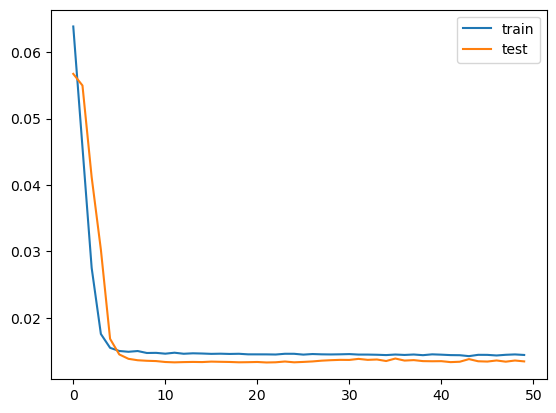

In [6]:
# design network
model = Sequential()
model.add(LSTM(50, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dense(1))
model.compile(loss='mae', optimizer='adam')
# fit network
history = model.fit(train_X, train_y, epochs=50, batch_size=72, validation_data=(test_X, test_y), verbose=2, shuffle=False)
# plot history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

## Evaluate Model
After the model is fit, we can forecast for the entire test dataset.

We combine the forecast with the test dataset and invert the scaling. We also invert scaling on the test dataset with the expected pollution numbers.

With forecasts and actual values in their original scale, we can then calculate an error score for the model. In this case, we calculate the Root Mean Squared Error (RMSE) that gives error in the same units as the variable itself.

In [14]:
import numpy as np
from math import sqrt
from sklearn.metrics import mean_squared_error

# inspect what the model expects
print("model.input_shape:", model.input_shape)

# make test arrays clean numeric arrays
test_X = np.asarray(test_X, dtype=np.float32)
test_y = np.asarray(test_y, dtype=np.float32)

print("before fix ->", type(test_X), test_X.shape, test_X.dtype, np.ndim(test_X))

# rebuild shape if needed
# expected shape is (samples, timesteps, features)
_, timesteps, n_features = model.input_shape

if test_X.ndim == 2:
    # this only works if timesteps == 1
    if timesteps != 1:
        raise ValueError(f"Model expects timesteps={timesteps}, but test_X is only 2D: {test_X.shape}")
    if test_X.shape[1] != n_features:
        raise ValueError(f"Expected {n_features} features, got {test_X.shape[1]}")
    test_X = test_X.reshape((test_X.shape[0], timesteps, n_features))

elif test_X.ndim == 3:
    if test_X.shape[1] != timesteps or test_X.shape[2] != n_features:
        raise ValueError(
            f"Wrong 3D shape. Expected (*, {timesteps}, {n_features}), got {test_X.shape}"
        )
else:
    raise ValueError(f"test_X must be 2D or 3D, got shape {test_X.shape}")

print("after fix  ->", test_X.shape, test_X.dtype, np.ndim(test_X))

# prediction
yhat = model.predict(test_X)

# flatten only after prediction
# this inverse-scaling logic assumes timesteps == 1
test_X_2d = test_X.reshape((test_X.shape[0], test_X.shape[2]))

# invert scaling for forecast
inv_yhat = np.concatenate((yhat, test_X_2d[:, 1:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:, 0]

# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y, test_X_2d[:, 1:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:, 0]

# RMSE
rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print("Test RMSE: %.3f" % rmse)

model.input_shape: (None, 1, 8)
before fix -> <class 'numpy.ndarray'> (35039, 8) float32 2
after fix  -> (35039, 1, 8) float32 3
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step
Test RMSE: 26.725


# Complete Example
The complete example is listed below.

NOTE: This example assumes you have prepared the data correctly, e.g. converted the downloaded “raw.csv” to the prepared “pollution.csv“. See the first part of this tutorial.


   var1(t-1)  var2(t-1)  var3(t-1)  var4(t-1)  var5(t-1)  var6(t-1)  \
1   0.129779   0.352941   0.245902   0.527273   0.666667   0.002290   
2   0.148893   0.367647   0.245902   0.527273   0.666667   0.003811   
3   0.159960   0.426471   0.229508   0.545454   0.666667   0.005332   
4   0.182093   0.485294   0.229508   0.563637   0.666667   0.008391   
5   0.138833   0.485294   0.229508   0.563637   0.666667   0.009912   

   var7(t-1)  var8(t-1)   var1(t)  
1   0.000000        0.0  0.148893  
2   0.000000        0.0  0.159960  
3   0.000000        0.0  0.182093  
4   0.037037        0.0  0.138833  
5   0.074074        0.0  0.109658  
(8760, 1, 8) (8760,) (35039, 1, 8) (35039,)
Epoch 1/50


/Users/olgademina/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


122/122 - 1s - 12ms/step - loss: 0.0572 - val_loss: 0.0610
Epoch 2/50
122/122 - 0s - 4ms/step - loss: 0.0398 - val_loss: 0.0627
Epoch 3/50
122/122 - 0s - 3ms/step - loss: 0.0240 - val_loss: 0.0475
Epoch 4/50
122/122 - 1s - 4ms/step - loss: 0.0177 - val_loss: 0.0395
Epoch 5/50
122/122 - 0s - 2ms/step - loss: 0.0159 - val_loss: 0.0264
Epoch 6/50
122/122 - 0s - 2ms/step - loss: 0.0150 - val_loss: 0.0184
Epoch 7/50
122/122 - 0s - 2ms/step - loss: 0.0150 - val_loss: 0.0169
Epoch 8/50
122/122 - 0s - 4ms/step - loss: 0.0149 - val_loss: 0.0155
Epoch 9/50
122/122 - 1s - 7ms/step - loss: 0.0148 - val_loss: 0.0154
Epoch 10/50
122/122 - 3s - 26ms/step - loss: 0.0148 - val_loss: 0.0150
Epoch 11/50
122/122 - 2s - 20ms/step - loss: 0.0148 - val_loss: 0.0147
Epoch 12/50
122/122 - 1s - 5ms/step - loss: 0.0147 - val_loss: 0.0143
Epoch 13/50
122/122 - 0s - 3ms/step - loss: 0.0146 - val_loss: 0.0145
Epoch 14/50
122/122 - 0s - 3ms/step - loss: 0.0147 - val_loss: 0.0140
Epoch 15/50
122/122 - 0s - 3ms/step -

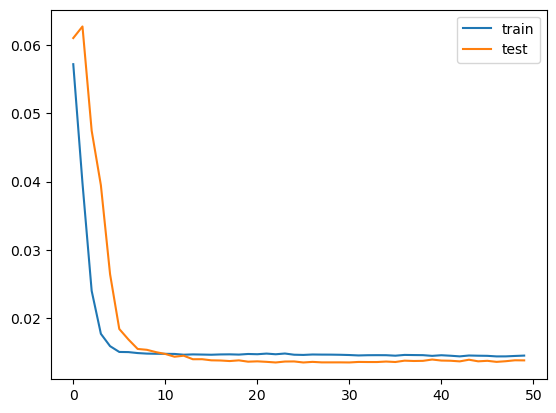

1095/1095 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step
Test RMSE: 26.725


In [13]:
from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
 
# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg
 
# load dataset
dataset = read_csv('pollution.csv', header=0, index_col=0)
values = dataset.values
# integer encode direction
encoder = LabelEncoder()
values[:,4] = encoder.fit_transform(values[:,4])
# ensure all data is float
values = values.astype('float32')
# normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
# frame as supervised learning
reframed = series_to_supervised(scaled, 1, 1)
# drop columns we don't want to predict
reframed.drop(reframed.columns[[9,10,11,12,13,14,15]], axis=1, inplace=True)
print(reframed.head())
 
# split into train and test sets
values = reframed.values
n_train_hours = 365 * 24
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]
# split into input and outputs
train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]
# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)
 
# design network
model = Sequential()
model.add(LSTM(50, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dense(1))
model.compile(loss='mae', optimizer='adam')
# fit network
history = model.fit(train_X, train_y, epochs=50, batch_size=72, validation_data=(test_X, test_y), verbose=2, shuffle=False)
# plot history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()
 
# make a prediction
yhat = model.predict(test_X)
test_X = test_X.reshape((test_X.shape[0], test_X.shape[2]))
# invert scaling for forecast
inv_yhat = concatenate((yhat, test_X[:, 1:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]
# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = concatenate((test_y, test_X[:, 1:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:,0]
# calculate RMSE
rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE: %.3f' % rmse)

Running the example first creates a plot showing the train and test loss during training.

Note: Your results may vary given the stochastic nature of the algorithm or evaluation procedure, or differences in numerical precision. Consider running the example a few times and compare the average outcome.

Interestingly, we can see that test loss drops below training loss. The model may be overfitting the training data. Measuring and plotting RMSE during training may shed more light on this.

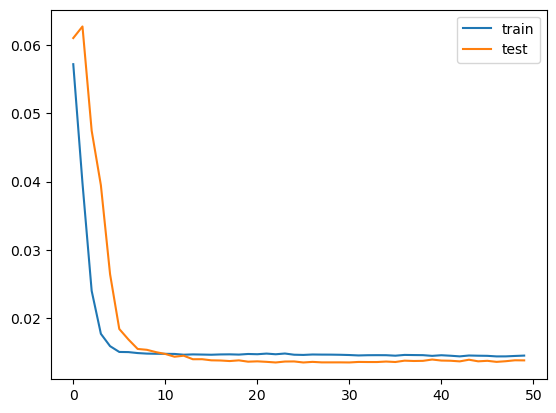

Test RMSE: 26.725


In [18]:
# plot history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()
print('Test RMSE: %.3f' % rmse)

    var1(t-24)  var2(t-24)  var3(t-24)  var4(t-24)  var5(t-24)  var6(t-24)  \
24    0.129779    0.214286    0.250000    0.528301    0.666667    0.002290   
25    0.148893    0.232143    0.250000    0.528301    0.666667    0.003811   
26    0.159960    0.303571    0.233333    0.547169    0.666667    0.005332   
27    0.182093    0.375000    0.233333    0.566038    0.666667    0.008391   
28    0.138833    0.375000    0.233333    0.566038    0.666667    0.009912   

    var7(t-24)  var8(t-24)  var1(t-23)  var2(t-23)  ...  var8(t-2)  var1(t-1)  \
24    0.000000         0.0    0.148893    0.232143  ...        0.0   0.126761   
25    0.000000         0.0    0.159960    0.303571  ...        0.0   0.090543   
26    0.000000         0.0    0.182093    0.375000  ...        0.0   0.063380   
27    0.037037         0.0    0.138833    0.375000  ...        0.0   0.065392   
28    0.074074         0.0    0.109658    0.375000  ...        0.0   0.055332   

    var2(t-1)  var3(t-1)  var4(t-1)  var5(t-

/Users/olgademina/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
411/411 - 9s - 22ms/step - loss: 0.0531 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 2/100
411/411 - 9s - 21ms/step - loss: 0.0426 - val_loss: 0.0347 - learning_rate: 0.0010
Epoch 3/100
411/411 - 9s - 21ms/step - loss: 0.0385 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 4/100
411/411 - 9s - 21ms/step - loss: 0.0361 - val_loss: 0.0277 - learning_rate: 0.0010
Epoch 5/100
411/411 - 8s - 19ms/step - loss: 0.0345 - val_loss: 0.0261 - learning_rate: 0.0010
Epoch 6/100
411/411 - 8s - 19ms/step - loss: 0.0333 - val_loss: 0.0288 - learning_rate: 0.0010
Epoch 7/100
411/411 - 8s - 20ms/step - loss: 0.0318 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 8/100
411/411 - 8s - 19ms/step - loss: 0.0307 - val_loss: 0.0277 - learning_rate: 0.0010
Epoch 9/100
411/411 - 8s - 20ms/step - loss: 0.0297 - val_loss: 0.0268 - learning_rate: 0.0010
Epoch 10/100
411/411 - 8s - 19ms/step - loss: 0.0283 - val_loss: 0.0286 - learning_rate: 5.0000e-04
Epoch 11/100
411/411 - 9s - 22ms/step - loss:

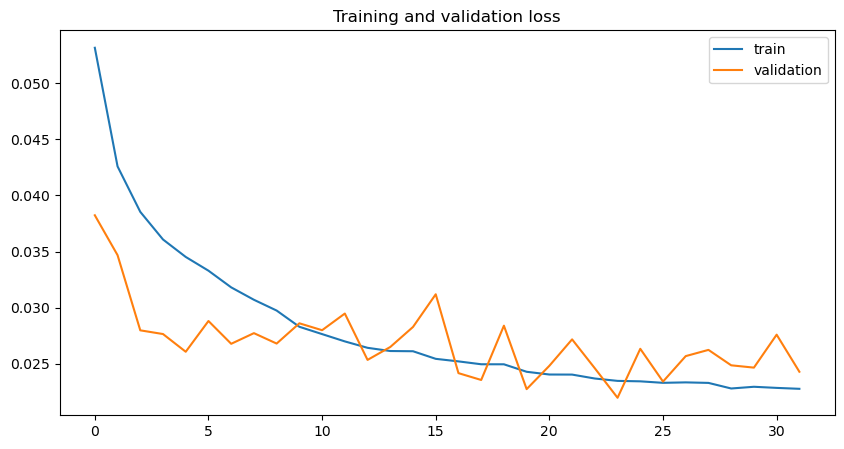

273/273 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test RMSE: 33.040


In [21]:
import numpy as np
import pandas as pd
from math import sqrt
from matplotlib import pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if isinstance(data, list) else data.shape[1]
    df = pd.DataFrame(data)
    cols, names = [], []

    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [f"var{j+1}(t-{i})" for j in range(n_vars)]

    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [f"var{j+1}(t)" for j in range(n_vars)]
        else:
            names += [f"var{j+1}(t+{i})" for j in range(n_vars)]

    agg = pd.concat(cols, axis=1)
    agg.columns = names

    if dropnan:
        agg.dropna(inplace=True)

    return agg


# -----------------------------
# 1. LOAD DATA
# -----------------------------
dataset = pd.read_csv("pollution.csv", header=0, index_col=0)

# keep original column order from your cleaned file:
# ['pollution', 'dew', 'temp', 'press', 'wnd_dir', 'wnd_spd', 'snow', 'rain']

values = dataset.values.copy()

# integer encode wind direction
encoder = LabelEncoder()
values[:, 4] = encoder.fit_transform(values[:, 4])

# ensure numeric
values = values.astype("float32")


# -----------------------------
# 2. TRAIN / VAL / TEST SPLIT
# -----------------------------
# better than 1 year train and everything else test
# here: 3 years train, 1 year val, 1 year test
hours_per_year = 365 * 24
train_end = 3 * hours_per_year
val_end = 4 * hours_per_year

train_raw = values[:train_end, :]
val_raw = values[train_end:val_end, :]
test_raw = values[val_end:, :]


# -----------------------------
# 3. SCALE WITHOUT LEAKAGE
# -----------------------------
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
val_scaled = scaler.transform(val_raw)
test_scaled = scaler.transform(test_raw)


# -----------------------------
# 4. CREATE SUPERVISED WINDOWS
# -----------------------------
# try 24 hours of history instead of 1 hour
n_hours = 24
n_features = train_scaled.shape[1]

train_sup = series_to_supervised(train_scaled, n_hours, 1)
val_sup = series_to_supervised(val_scaled, n_hours, 1)
test_sup = series_to_supervised(test_scaled, n_hours, 1)

# keep only inputs + pollution target at time t
# all current-time columns except var1(t) are dropped
drop_cols = list(range(n_hours * n_features + 1, (n_hours + 1) * n_features))

train_sup.drop(train_sup.columns[drop_cols], axis=1, inplace=True)
val_sup.drop(val_sup.columns[drop_cols], axis=1, inplace=True)
test_sup.drop(test_sup.columns[drop_cols], axis=1, inplace=True)

print(train_sup.head())


# -----------------------------
# 5. SPLIT X / y
# -----------------------------
train_values = train_sup.values
val_values = val_sup.values
test_values = test_sup.values

train_X, train_y = train_values[:, :-1], train_values[:, -1]
val_X, val_y = val_values[:, :-1], val_values[:, -1]
test_X, test_y = test_values[:, :-1], test_values[:, -1]

# reshape to 3D: [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], n_hours, n_features))
val_X = val_X.reshape((val_X.shape[0], n_hours, n_features))
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))

print("train_X:", train_X.shape, "train_y:", train_y.shape)
print("val_X:  ", val_X.shape, "val_y:  ", val_y.shape)
print("test_X: ", test_X.shape, "test_y: ", test_y.shape)


# -----------------------------
# 6. BETTER MODEL
# -----------------------------
model = Sequential([
    LSTM(
        64,
        input_shape=(train_X.shape[1], train_X.shape[2]),
        return_sequences=True,
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    LSTM(
        32,
        dropout=0.2,
        recurrent_dropout=0.2
    ),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1)
])

model.compile(loss="mae", optimizer="adam")
model.summary()


# -----------------------------
# 7. CALLBACKS
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5
)


# -----------------------------
# 8. TRAIN
# -----------------------------
history = model.fit(
    train_X,
    train_y,
    epochs=100,
    batch_size=64,
    validation_data=(val_X, val_y),
    verbose=2,
    shuffle=False,
    callbacks=[early_stop, reduce_lr]
)


# -----------------------------
# 9. PLOT TRAINING HISTORY
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Training and validation loss")
plt.legend()
plt.show()


# -----------------------------
# 10. PREDICT
# -----------------------------
yhat = model.predict(test_X)

# flatten test_X back to 2D for inverse scaling
test_X_2d = test_X.reshape((test_X.shape[0], n_hours * n_features))

# we need the other features at time t for inverse scaling
# after reframing, the last block of 8 features corresponds to time t
# among those, pollution(t) was kept as y, and the rest are in the tail
current_t_features_excluding_target = test_X_2d[:, -(n_features - 1):]

# invert scaling for forecast
inv_yhat = np.concatenate((yhat, current_t_features_excluding_target), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:, 0]

# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y, current_t_features_excluding_target), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:, 0]

# calculate RMSE
rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print("Test RMSE: %.3f" % rmse)

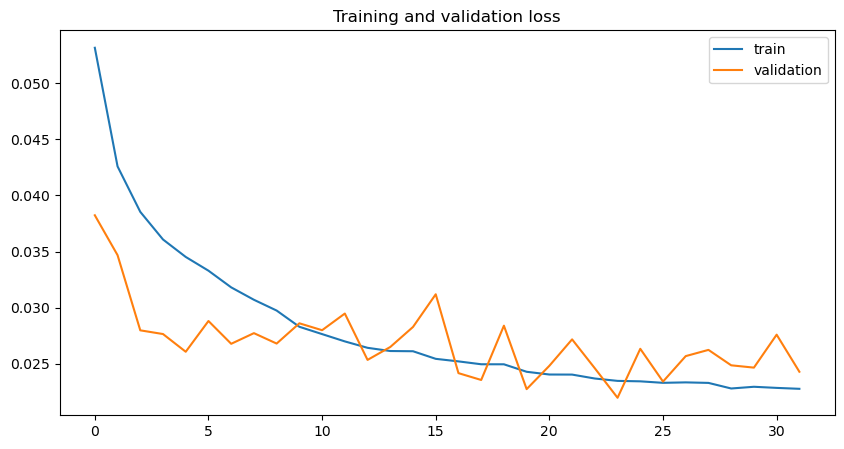

1095/1095 ━━━━━━━━━━━━━━━━━━━━ 1s 662us/step
Test RMSE: 107.895


In [23]:

# -----------------------------
# 9. PLOT TRAINING HISTORY
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Training and validation loss")
plt.legend()
plt.show()


# -----------------------------
# 10. PREDICT
# -----------------------------
yhat = model.predict(test_X)

# flatten test_X back to 2D for inverse scaling
test_X_2d = test_X.reshape((test_X.shape[0], n_hours * n_features))

# we need the other features at time t for inverse scaling
# after reframing, the last block of 8 features corresponds to time t
# among those, pollution(t) was kept as y, and the rest are in the tail
current_t_features_excluding_target = test_X_2d[:, -(n_features - 1):]

# invert scaling for forecast
inv_yhat = np.concatenate((yhat, current_t_features_excluding_target), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:, 0]

# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y, current_t_features_excluding_target), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:, 0]

# calculate RMSE
rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print("Test RMSE: %.3f" % rmse)

# Train On Multiple Lag Timesteps Example
There have been many requests for advice on how to adapt the above example to train the model on multiple previous time steps.

I had tried this and a myriad of other configurations when writing the original post and decided not to include them because they did not lift model skill.

Nevertheless, I have included this example below as reference template that you could adapt for your own problems.

The changes needed to train the model on multiple previous time steps are quite minimal, as follows:

First, you must frame the problem suitably when calling series_to_supervised(). We will use 3 hours of data as input. Also note, we no longer explictly drop the columns from all of the other fields at ob(t).

In [19]:

# specify the number of lag hours
n_hours = 3
n_features = 8
# frame as supervised learning
reframed = series_to_supervised(scaled, n_hours, 1)

Next, we need to be more careful in specifying the column for input and output.

We have 3 * 8 + 8 columns in our framed dataset. We will take 3 * 8 or 24 columns as input for the obs of all features across the previous 3 hours. We will take just the pollution variable as output at the following hour, as follows:

In [22]:

# if you actually want 3 hours, rebuild the supervised dataset first

n_hours = 3
n_features = 8

reframed = series_to_supervised(scaled, n_in=n_hours, n_out=1)

values = reframed.values
n_train_hours = 365 * 24
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]

n_obs = n_hours * n_features
train_X, train_y = train[:, :n_obs], train[:, -1]
test_X, test_y = test[:, :n_obs], test[:, -1]
# and reshape our input data correctly to reflect the time steps and features.

# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], n_hours, n_features))
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))

print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(8760, 3, 8) (8760,) (35037, 3, 8) (35037,)


Fitting the model is the same.

The only other small change is in how to evaluate the model. Specifically, in how we reconstruct the rows with 8 columns suitable for reversing the scaling operation to get the y and yhat back into the original scale so that we can calculate the RMSE.

The gist of the change is that we concatenate the y or yhat column with the last 7 features of the test dataset in order to inverse the scaling, as follows:

In [25]:

# invert scaling for forecast
n_features = 8
n_other_features = n_features - 1

yhat = model.predict(test_X)
test_X_2d = test_X.reshape((test_X.shape[0], n_hours * n_features))

last_step_features_except_target = test_X_2d[:, -n_other_features:]

inv_yhat = concatenate((yhat, last_step_features_except_target), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)[:, 0]

test_y = test_y.reshape((len(test_y), 1))
inv_y = concatenate((test_y, last_step_features_except_target), axis=1)
inv_y = scaler.inverse_transform(inv_y)[:, 0]

# We can tie all of these modifications to the above example together. The complete example of multvariate time series forecasting with multiple lag inputs is listed below:



1095/1095 ━━━━━━━━━━━━━━━━━━━━ 1s 524us/step


(43797, 32)
(8760, 24) 8760 (8760,)
(8760, 3, 8) (8760,) (35037, 3, 8) (35037,)
Epoch 1/50


/Users/olgademina/anaconda3/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


122/122 - 2s - 13ms/step - loss: 0.0502 - val_loss: 0.0389
Epoch 2/50
122/122 - 0s - 4ms/step - loss: 0.0254 - val_loss: 0.0239
Epoch 3/50
122/122 - 0s - 3ms/step - loss: 0.0209 - val_loss: 0.0205
Epoch 4/50
122/122 - 0s - 2ms/step - loss: 0.0205 - val_loss: 0.0198
Epoch 5/50
122/122 - 0s - 3ms/step - loss: 0.0200 - val_loss: 0.0190
Epoch 6/50
122/122 - 0s - 2ms/step - loss: 0.0200 - val_loss: 0.0179
Epoch 7/50
122/122 - 0s - 2ms/step - loss: 0.0197 - val_loss: 0.0177
Epoch 8/50
122/122 - 0s - 2ms/step - loss: 0.0189 - val_loss: 0.0179
Epoch 9/50
122/122 - 0s - 3ms/step - loss: 0.0185 - val_loss: 0.0178
Epoch 10/50
122/122 - 0s - 2ms/step - loss: 0.0181 - val_loss: 0.0171
Epoch 11/50
122/122 - 0s - 2ms/step - loss: 0.0181 - val_loss: 0.0167
Epoch 12/50
122/122 - 0s - 3ms/step - loss: 0.0173 - val_loss: 0.0163
Epoch 13/50
122/122 - 0s - 3ms/step - loss: 0.0171 - val_loss: 0.0159
Epoch 14/50
122/122 - 0s - 3ms/step - loss: 0.0169 - val_loss: 0.0167
Epoch 15/50
122/122 - 0s - 2ms/step - l

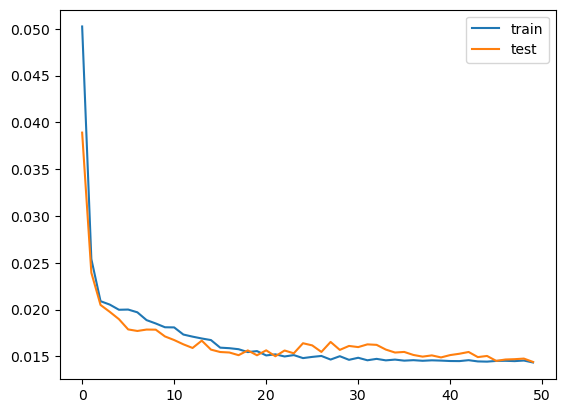

1095/1095 ━━━━━━━━━━━━━━━━━━━━ 1s 404us/step
Test RMSE: 26.758


In [26]:
from math import sqrt
from numpy import concatenate
from matplotlib import pyplot
from pandas import read_csv
from pandas import DataFrame
from pandas import concat
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM

# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	n_vars = 1 if type(data) is list else data.shape[1]
	df = DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

# load dataset
dataset = read_csv('pollution.csv', header=0, index_col=0)
values = dataset.values
# integer encode direction
encoder = LabelEncoder()
values[:,4] = encoder.fit_transform(values[:,4])
# ensure all data is float
values = values.astype('float32')
# normalize features
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)
# specify the number of lag hours
n_hours = 3
n_features = 8
# frame as supervised learning
reframed = series_to_supervised(scaled, n_hours, 1)
print(reframed.shape)

# split into train and test sets
values = reframed.values
n_train_hours = 365 * 24
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]
# split into input and outputs
n_obs = n_hours * n_features
train_X, train_y = train[:, :n_obs], train[:, -n_features]
test_X, test_y = test[:, :n_obs], test[:, -n_features]
print(train_X.shape, len(train_X), train_y.shape)
# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], n_hours, n_features))
test_X = test_X.reshape((test_X.shape[0], n_hours, n_features))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

# design network
model = Sequential()
model.add(LSTM(50, input_shape=(train_X.shape[1], train_X.shape[2])))
model.add(Dense(1))
model.compile(loss='mae', optimizer='adam')
# fit network
history = model.fit(train_X, train_y, epochs=50, batch_size=72, validation_data=(test_X, test_y), verbose=2, shuffle=False)
# plot history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

# make a prediction
yhat = model.predict(test_X)
test_X = test_X.reshape((test_X.shape[0], n_hours*n_features))
# invert scaling for forecast
inv_yhat = concatenate((yhat, test_X[:, -7:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]
# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = concatenate((test_y, test_X[:, -7:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:,0]
# calculate RMSE
rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE: %.3f' % rmse)

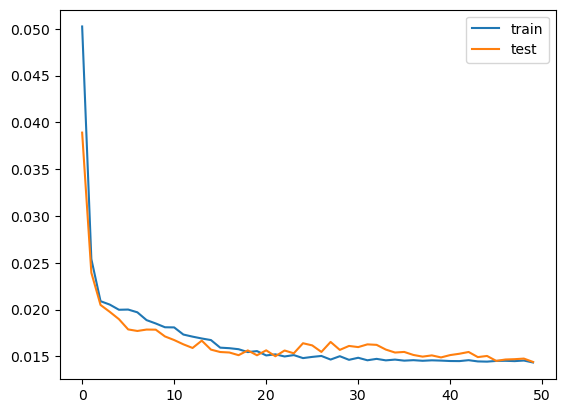

In [27]:
# plot history
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()